In [1]:
from PIL import Image
import os, sys
import torch

In [2]:
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
GITHUB_TOKEN = secrets.get_secret("GITHUB_TOKEN")

os.system(f'git clone https://{GITHUB_TOKEN}@github.com/m-j-r-q/Cura.git /kaggle/working/Cura')
sys.path.append('/kaggle/working/Cura/backend/src')

IMAGE_DIR  = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224'
DATA_DIR = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized'
CSV_PATH  = f'{DATA_DIR}/Data_Entry_2017.csv'

Cloning into '/kaggle/working/Cura'...
Updating files: 100% (24/24), done.


In [3]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df.columns.tolist())

(112120, 12)
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [4]:
df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN
5,00000003_001.png,Hernia,1,3,074Y,F,PA,2500,2048,0.168,0.168,NaN
6,00000003_002.png,Hernia,2,3,075Y,F,PA,2048,2500,0.168,0.168,NaN
7,00000003_003.png,Hernia|Infiltration,3,3,076Y,F,PA,2698,2991,0.143,0.143,NaN
8,00000003_004.png,Hernia,4,3,077Y,F,PA,2500,2048,0.168,0.168,NaN
9,00000003_005.png,Hernia,5,3,078Y,F,PA,2686,2991,0.143,0.143,NaN


In [5]:
from collections import Counter

all_labels = []
for entry in df['Finding Labels']:
    all_labels.extend(entry.split('|'))

label_counts = Counter(all_labels)

for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"{label:30} {count:6}  ({count/112120*100:.1f}%)")

No Finding                      60412  (53.9%)
Infiltration                    19870  (17.7%)
Effusion                        13307  (11.9%)
Atelectasis                     11535  (10.3%)
Nodule                           6323  (5.6%)
Mass                             5746  (5.1%)
Pneumothorax                     5298  (4.7%)
Consolidation                    4667  (4.2%)
Pleural_Thickening               3385  (3.0%)
Cardiomegaly                     2772  (2.5%)
Emphysema                        2516  (2.2%)
Edema                            2303  (2.1%)
Fibrosis                         1686  (1.5%)
Pneumonia                        1353  (1.2%)
Hernia                            227  (0.2%)


In [6]:
import os

available_images = set(os.listdir(IMAGE_DIR))

print(f"Images available on disk: {len(available_images)}")
print(f"Images referenced in CSV: {len(df)}")

df['available'] = df['Image Index'].isin(available_images)
print(f"CSV entries with missing images: {(~df['available']).sum()}")

Images available on disk: 112120
Images referenced in CSV: 112120
CSV entries with missing images: 0


In [7]:
df_filtered = df[df['available'] == True].reset_index(drop=True)

print(f"Working dataset size: {len(df_filtered)}")

all_labels_filtered = []
for entry in df_filtered['Finding Labels']:
    all_labels_filtered.extend(entry.split('|'))

label_counts_filtered = Counter(all_labels_filtered)
for label, count in sorted(label_counts_filtered.items(), key=lambda x: -x[1]):
    print(f"{label:30} {count:6}  ({count/len(df_filtered)*100:.1f}%)")

Working dataset size: 112120
No Finding                      60412  (53.9%)
Infiltration                    19870  (17.7%)
Effusion                        13307  (11.9%)
Atelectasis                     11535  (10.3%)
Nodule                           6323  (5.6%)
Mass                             5746  (5.1%)
Pneumothorax                     5298  (4.7%)
Consolidation                    4667  (4.2%)
Pleural_Thickening               3385  (3.0%)
Cardiomegaly                     2772  (2.5%)
Emphysema                        2516  (2.2%)
Edema                            2303  (2.1%)
Fibrosis                         1686  (1.5%)
Pneumonia                        1353  (1.2%)
Hernia                            227  (0.2%)


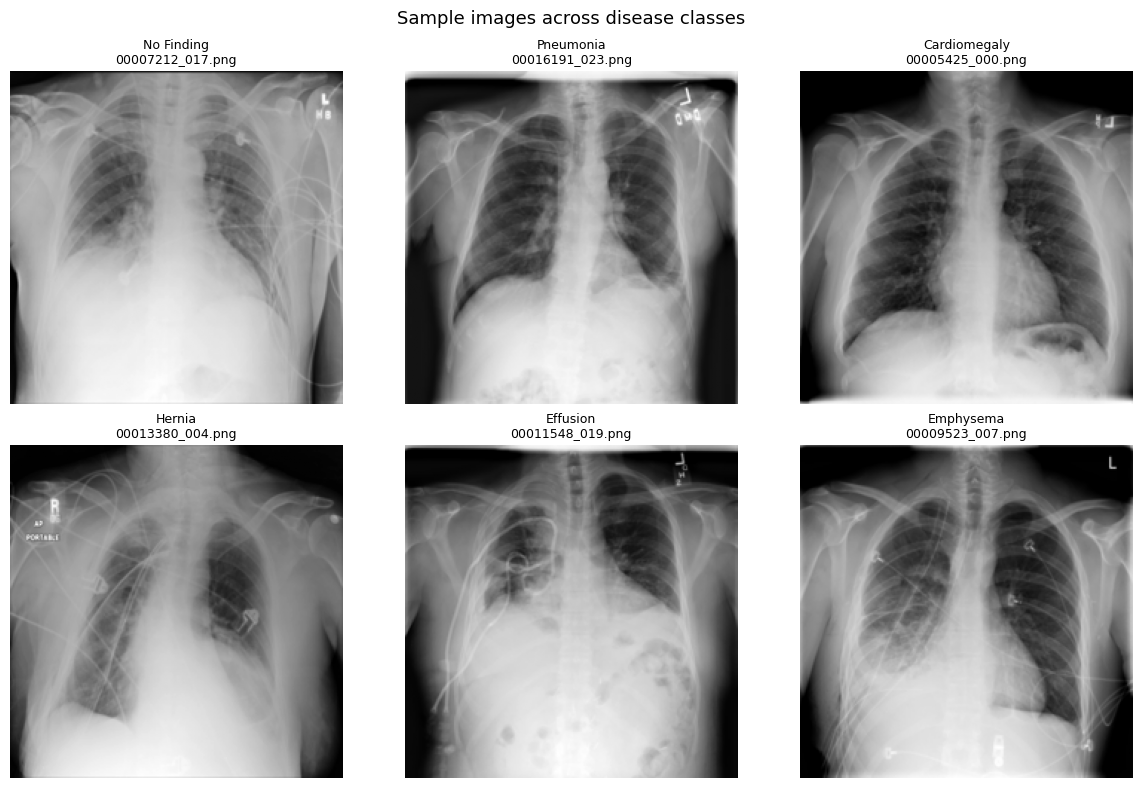

In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

samples = {
    'No Finding': df[df['Finding Labels'] == 'No Finding'].sample(1).iloc[0],
    'Pneumonia': df[df['Finding Labels'].str.contains('Pneumonia')].sample(1).iloc[0],
    'Cardiomegaly': df[df['Finding Labels'].str.contains('Cardiomegaly')].sample(1).iloc[0],
    'Hernia': df[df['Finding Labels'].str.contains('Hernia')].sample(1).iloc[0],
    'Effusion': df[df['Finding Labels'].str.contains('Effusion')].sample(1).iloc[0],
    'Emphysema': df[df['Finding Labels'].str.contains('Emphysema')].sample(1).iloc[0],
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, row) in enumerate(samples.items()):
    img_path = f"{IMAGE_DIR}/{row['Image Index']}"
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{label}\n{row['Image Index']}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Sample images across disease classes', fontsize=13)
plt.tight_layout()
plt.show()